In [43]:
import pandas as pd

# Load feature engineered dataset
df = pd.read_csv("../Data/climate_features.csv")

print(df.head())

     T2M  T2M_MAX  T2M_MIN   RH2M  WS10M  PRECTOTCORR        DATE  YEAR  \
0  17.57    25.56     9.91  52.72   2.82         0.00  2000-01-30  2000   
1  18.72    26.47    11.38  49.07   1.63         0.00  2000-01-31  2000   
2  19.44    28.00    12.55  57.41   2.58         0.00  2000-02-01  2000   
3  21.16    28.40    15.45  75.70   4.02         4.26  2000-02-02  2000   
4  22.05    28.52    17.14  75.62   2.31         4.78  2000-02-03  2000   

   MONTH  HEAVY_RAIN  HEATWAVE  EXTREME_RAIN  TEMP_ANOMALY  TEMP_MA30  \
0      1       False         0             0     -8.278686  17.609667   
1      1       False         0             0     -7.128686  17.699333   
2      2       False         0             0     -6.408686  17.818667   
3      2       False         0             0     -4.688686  18.014000   
4      2       False         0             0     -3.798686  18.236667   

   TEMP_RANGE   TEMP_MA7  RAIN_MA7  
0       15.65  18.638571  0.058571  
1       15.09  18.547143  0.058571  

In [44]:
# Features
X = df[[
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "WS10M",
    "TEMP_RANGE",
    "TEMP_ANOMALY",
    "TEMP_MA7",
    "RAIN_MA7"
]]

# Target
y = df["PRECTOTCORR"]

In [45]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [46]:
from xgboost import XGBRegressor

In [47]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [48]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [49]:
pred = model.predict(X_test)

In [50]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 6.675152589395815
R² Score: 0.5442730076381204


RMSE: 5.015538526538267
R² Score: 0.6973834214788392


C:\Users\avisw\AppData\Local\Temp\ipykernel_25712\4265400535.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


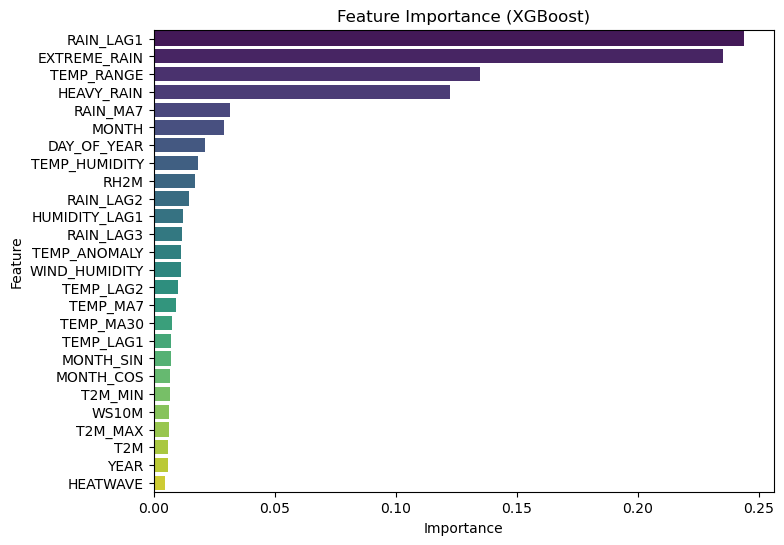

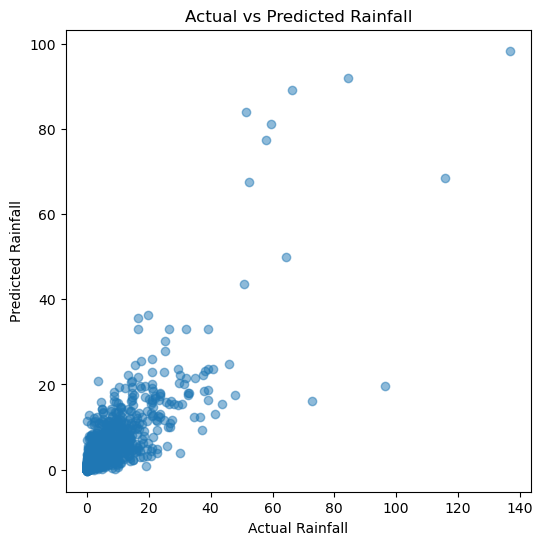

In [51]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../Data/climate_features.csv")

# Ensure date format
df["DATE"] = pd.to_datetime(df["DATE"])

# ---------- Feature Engineering Improvements ----------

# Lag features
df["RAIN_LAG1"] = df["PRECTOTCORR"].shift(1)
df["RAIN_LAG2"] = df["PRECTOTCORR"].shift(2)
df["RAIN_LAG3"] = df["PRECTOTCORR"].shift(3)

df["TEMP_LAG1"] = df["T2M"].shift(1)
df["TEMP_LAG2"] = df["T2M"].shift(2)

df["HUMIDITY_LAG1"] = df["RH2M"].shift(1)

# Seasonality features
df["MONTH"] = df["DATE"].dt.month
df["DAY_OF_YEAR"] = df["DATE"].dt.dayofyear

df["MONTH_SIN"] = np.sin(2*np.pi*df["MONTH"]/12)
df["MONTH_COS"] = np.cos(2*np.pi*df["MONTH"]/12)

# Interaction features
df["TEMP_HUMIDITY"] = df["T2M"] * df["RH2M"]
df["WIND_HUMIDITY"] = df["WS10M"] * df["RH2M"]

# Drop missing rows from lag features
df = df.dropna()

# ---------- Prepare ML Data ----------

X = df.drop(columns=["PRECTOTCORR","DATE"])
y = np.log1p(df["PRECTOTCORR"])   # log transform rainfall

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- XGBoost Model ----------

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

# ---------- Predictions ----------

pred_log = model.predict(X_test)
pred = np.expm1(pred_log)   # reverse log transform
y_test_actual = np.expm1(y_test)

# ---------- Evaluation ----------

rmse = np.sqrt(mean_squared_error(y_test_actual, pred))
r2 = r2_score(y_test_actual, pred)

print("RMSE:", rmse)
print("R² Score:", r2)

# ---------- Feature Importance ----------

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance (XGBoost)")
plt.show()

# ---------- Actual vs Predicted ----------

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, pred, alpha=0.5)
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted Rainfall")
plt.show()

Rain/No-Rain Classification Accuracy: 0.9053905390539054
Hybrid Model RMSE: 4.936087142069146
Hybrid Model R²: 0.5822990997538369


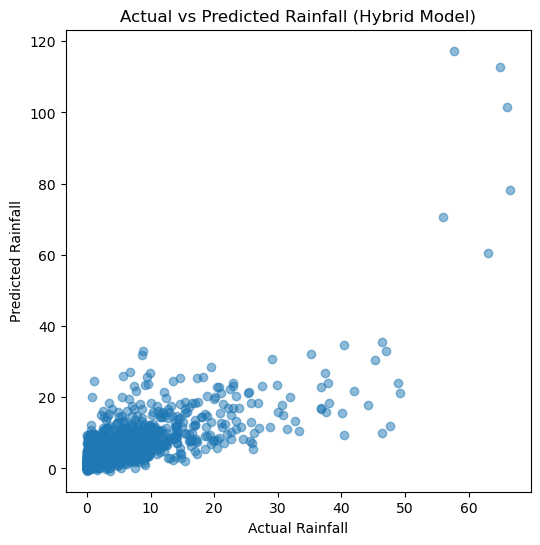

In [ ]:
""""import pandas as pd
import numpy as np
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../Data/climate_features.csv")
df["DATE"] = pd.to_datetime(df["DATE"])

# ---------- Additional Features ----------
df["RAIN_SUM7"] = df["PRECTOTCORR"].rolling(7).sum()
df["RAIN_MA14"] = df["PRECTOTCORR"].rolling(14).mean()

df = df.dropna()

# ---------- Classification Target ----------
df["RAIN_EVENT"] = (df["PRECTOTCORR"] > 0).astype(int)

# ---------- Features ----------
X = df.drop(columns=["PRECTOTCORR","RAIN_EVENT","DATE"])
y_reg = df["PRECTOTCORR"]
y_clf = df["RAIN_EVENT"]

# ---------- Train/Test Split ----------
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

y_clf_train = y_clf.loc[X_train.index]
y_clf_test = y_clf.loc[X_test.index]

# ---------- Step 1: Rain / No Rain Classifier ----------
clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

clf.fit(X_train, y_clf_train)

rain_pred_class = clf.predict(X_test)

print("Rain/No-Rain Classification Accuracy:",
      accuracy_score(y_clf_test, rain_pred_class))

# ---------- Step 2: Rainfall Amount Regression ----------
# Train regression only on rainy days
rainy_idx = y_reg_train > 0

reg = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

reg.fit(X_train[rainy_idx], y_reg_train[rainy_idx])

rain_amount_pred = reg.predict(X_test)

# ---------- Hybrid Prediction ----------
final_pred = rain_amount_pred * rain_pred_class

# ---------- Evaluation ----------
rmse = np.sqrt(mean_squared_error(y_reg_test, final_pred))
r2 = r2_score(y_reg_test, final_pred)

print("Hybrid Model RMSE:", rmse)
print("Hybrid Model R²:", r2)

# ---------- Visualization ----------
plt.figure(figsize=(6,6))
plt.scatter(y_reg_test, final_pred, alpha=0.5)
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted Rainfall (Hybrid Model)")
plt.show()"""